In [1]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt 


2025-10-28 16:07:16.807209: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-28 16:07:16.811885: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-28 16:07:16.826836: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761664036.852836   25863 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761664036.864694   25863 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761664036.889166   25863 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [6]:
db_path="./"
img_width,img_hight= 32,32
batch_size=20
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    db_path+"clouds_train",
    image_size=(img_width, img_hight),
    batch_size=batch_size
)
test_db = tf.keras.preprocessing.image_dataset_from_directory(
    db_path+"clouds_test",
    image_size=(img_width, img_hight),
    batch_size=batch_size
)

Found 474 files belonging to 7 classes.
Found 486 files belonging to 7 classes.


['cirriform clouds', 'clear sky', 'cumulonimbus clouds', 'cumulus clouds', 'high cumuliform clouds', 'stratiform clouds', 'stratocumulus clouds']


2025-10-28 16:08:01.475019: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


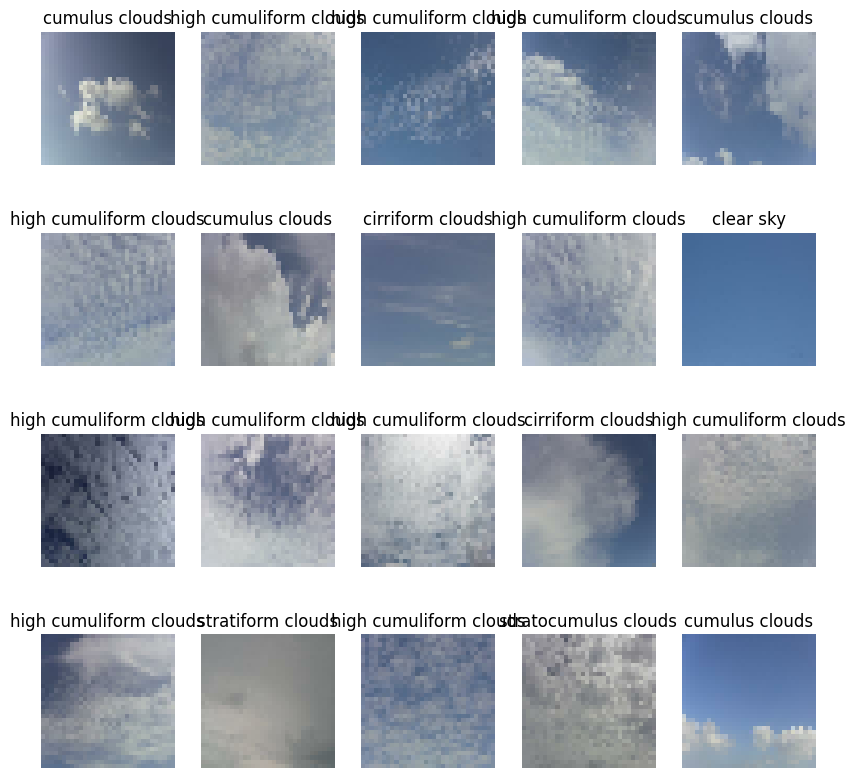

In [7]:
class_names = train_ds.class_names
print(class_names)
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(20):
        ax = plt.subplot(4, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(64, (3, 3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3, 3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3, 3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

In [9]:
with tf.device('/GPU:0'):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

In [10]:
model.fit(
    train_ds,
    validation_data=validate_db,
    epochs=10,
    verbose=2
)

Epoch 1/10


23/23 - 4s - 181ms/step - accuracy: 0.6739 - loss: 0.7406 - val_accuracy: 0.7576 - val_loss: 0.4494
Epoch 2/10
23/23 - 1s - 64ms/step - accuracy: 0.8739 - loss: 0.3345 - val_accuracy: 0.9091 - val_loss: 0.2796
Epoch 3/10
23/23 - 2s - 103ms/step - accuracy: 0.9435 - loss: 0.1782 - val_accuracy: 0.9394 - val_loss: 0.1801
Epoch 4/10
23/23 - 1s - 62ms/step - accuracy: 0.9609 - loss: 0.1135 - val_accuracy: 0.8485 - val_loss: 0.6739
Epoch 5/10
23/23 - 1s - 61ms/step - accuracy: 0.9130 - loss: 0.2045 - val_accuracy: 0.9394 - val_loss: 0.2162
Epoch 6/10
23/23 - 3s - 115ms/step - accuracy: 0.9652 - loss: 0.0877 - val_accuracy: 0.9394 - val_loss: 0.1341
Epoch 7/10
23/23 - 1s - 59ms/step - accuracy: 0.9848 - loss: 0.0664 - val_accuracy: 0.9091 - val_loss: 0.2042
Epoch 8/10
23/23 - 1s - 50ms/step - accuracy: 0.9848 - loss: 0.0598 - val_accuracy: 0.9242 - val_loss: 0.2162
Epoch 9/10
23/23 - 1s - 57ms/step - accuracy: 0.9891 - loss: 0.0392 - val_accuracy: 0.9394 - val_loss: 0.1587
Epoch 10/10
23/23 

In [11]:
model.evaluate(test_db,verbose=2)

7/7 - 0s - 36ms/step - accuracy: 0.9615 - loss: 0.0802


[0.0801633819937706, 0.9615384340286255]

In [12]:
model.save("fruit_classification_model_95-38.h5")

In [13]:
for images,labels in test_db.take(1):
    predictions = model.predict(images)
    predicted_classes=np.argmax(predictions,axis=1)
    for i in range(len(images)):
        print("Predicted: {}, Actual: {}".format(class_names[predicted_classes[i]],class_names[labels[i]]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Predicted: orange, Actual: orange
Predicted: banana, Actual: banana
Predicted: banana, Actual: banana
Predicted: orange, Actual: orange
Predicted: apple, Actual: apple
Predicted: banana, Actual: banana
Predicted: banana, Actual: banana
Predicted: orange, Actual: orange
Predicted: apple, Actual: apple
Predicted: banana, Actual: banana
Predicted: orange, Actual: orange
Predicted: apple, Actual: apple
Predicted: banana, Actual: banana
Predicted: orange, Actual: orange
Predicted: apple, Actual: apple
Predicted: apple, Actual: apple
Predicted: apple, Actual: apple
Predicted: apple, Actual: apple
Predicted: orange, Actual: orange
Predicted: banana, Actual: apple


2025-10-28 15:50:31.427024: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
